In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

import warnings
warnings.filterwarnings("ignore")

In [49]:
import pandas as pd

df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [50]:
df.shape

(7043, 21)

In [51]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [53]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [54]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [55]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [58]:
df["TotalCharges"].dtype

dtype('O')

In [59]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [60]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [61]:
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

In [62]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [63]:
df["TotalCharges"].dtype

dtype('float64')

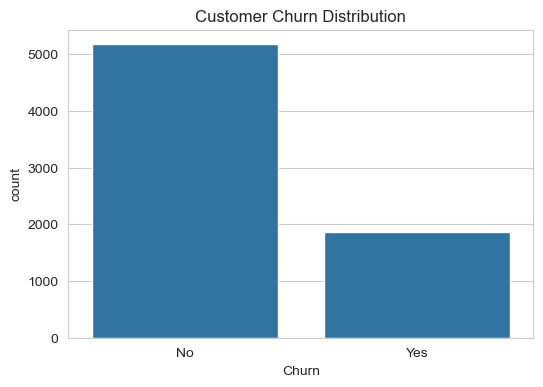

In [64]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()

Observation:

Most customers have not churned.

Dataset is moderately imbalanced.

In [65]:
churn_rate = (
    df["Churn"]
    .value_counts(normalize=True)
    * 100
)

churn_rate

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

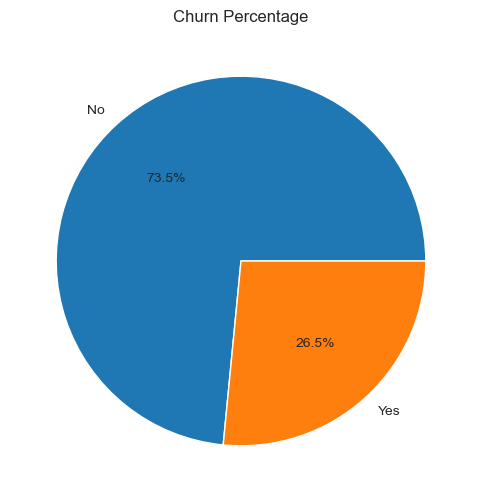

In [66]:
plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Churn Percentage")
plt.ylabel("")
plt.show()

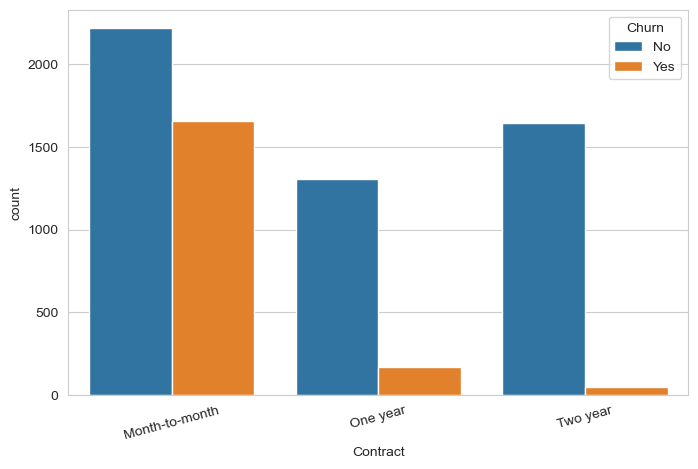

In [67]:
# Which contract type churns most?

plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.xticks(rotation=15)
plt.show()

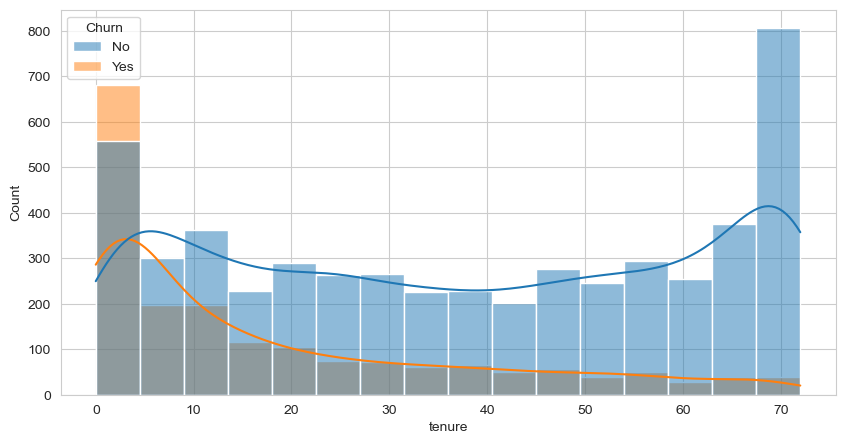

In [68]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    kde=True
)

plt.show()

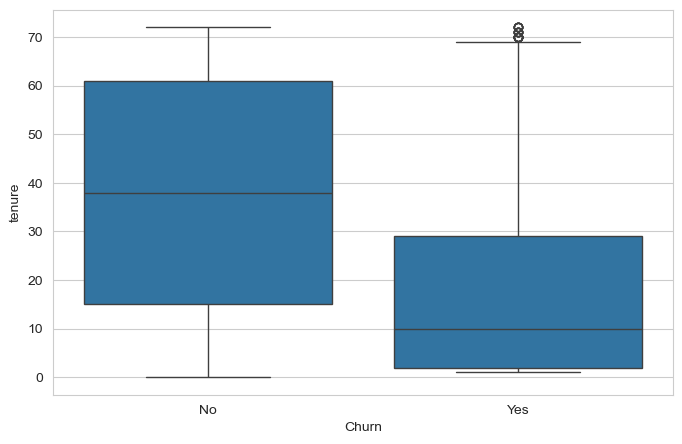

In [69]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.show()


 Customers with shorter tenure are more likely to churn.

#### Monthly Charges Analysis

Does pricing affect churn?


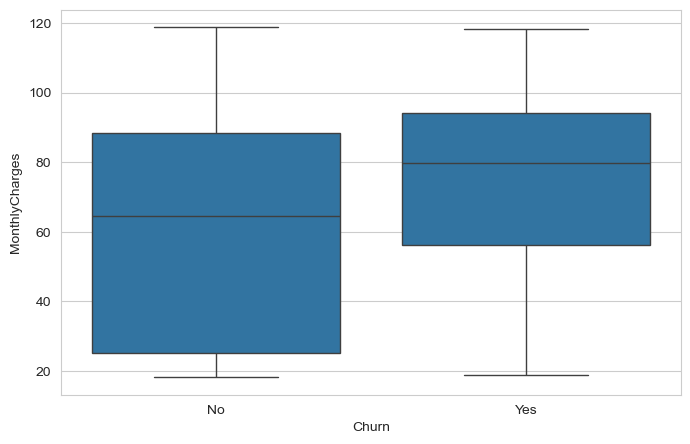

In [70]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.show()

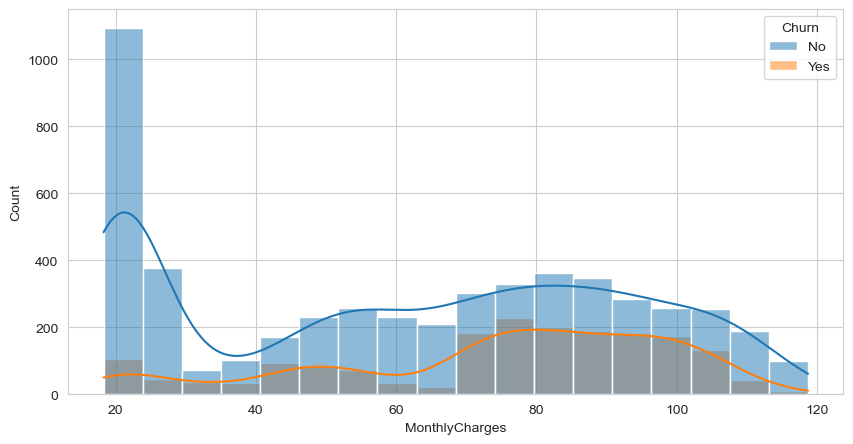

In [71]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    kde=True
)

plt.show()

Customers paying higher monthly charges tend to churn more frequently.

### Internet Service Analysis

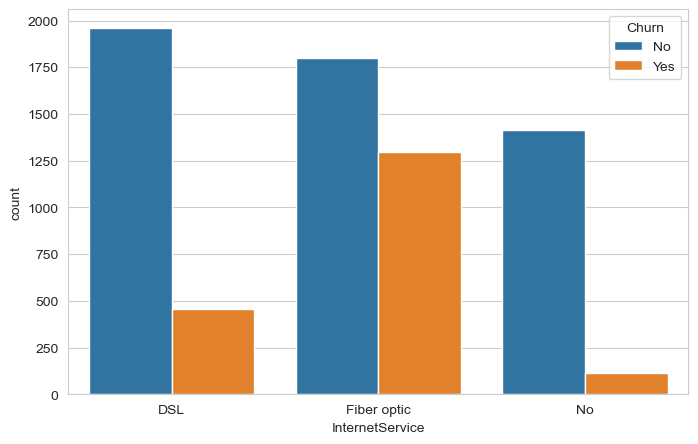

In [72]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.show()

Fiber optic users appear to churn at a higher rate.

### Payment Method Analysis

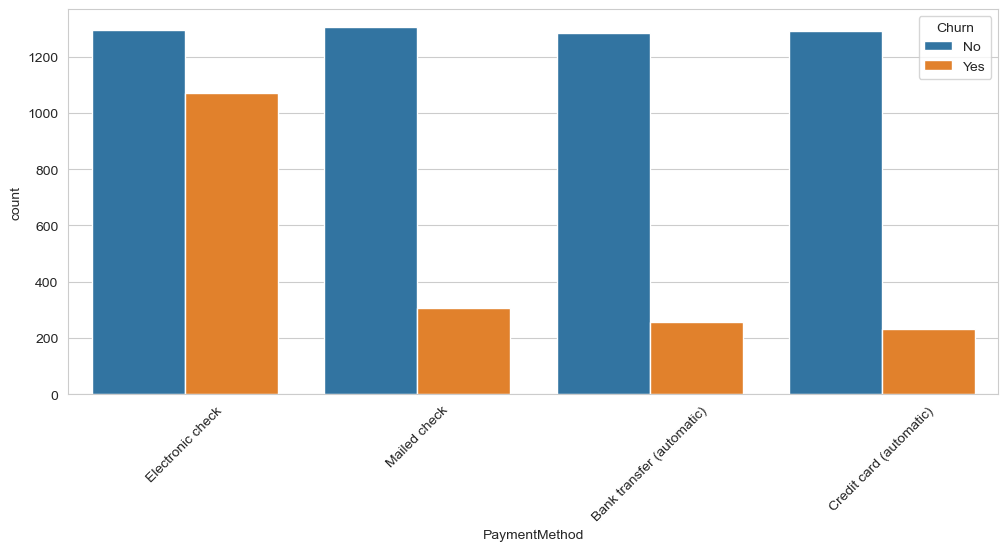

In [73]:
plt.figure(figsize=(12,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)
plt.show()

### Senior Citizen Analysis


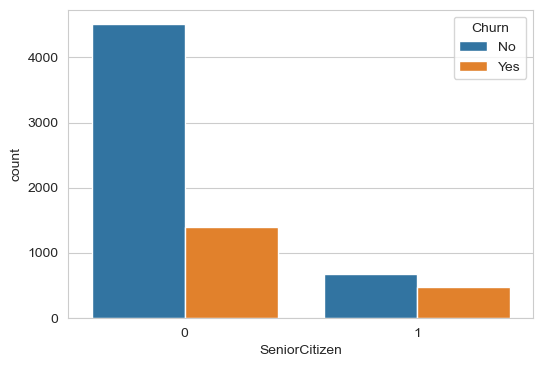

In [74]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="SeniorCitizen",
    hue="Churn",
    data=df
)

plt.show()

In [75]:
temp_df = df.copy()

### Correlation Analysis

In [76]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in temp_df.columns:
    if temp_df[col].dtype == "object":
        temp_df[col] = le.fit_transform(
            temp_df[col]
        )

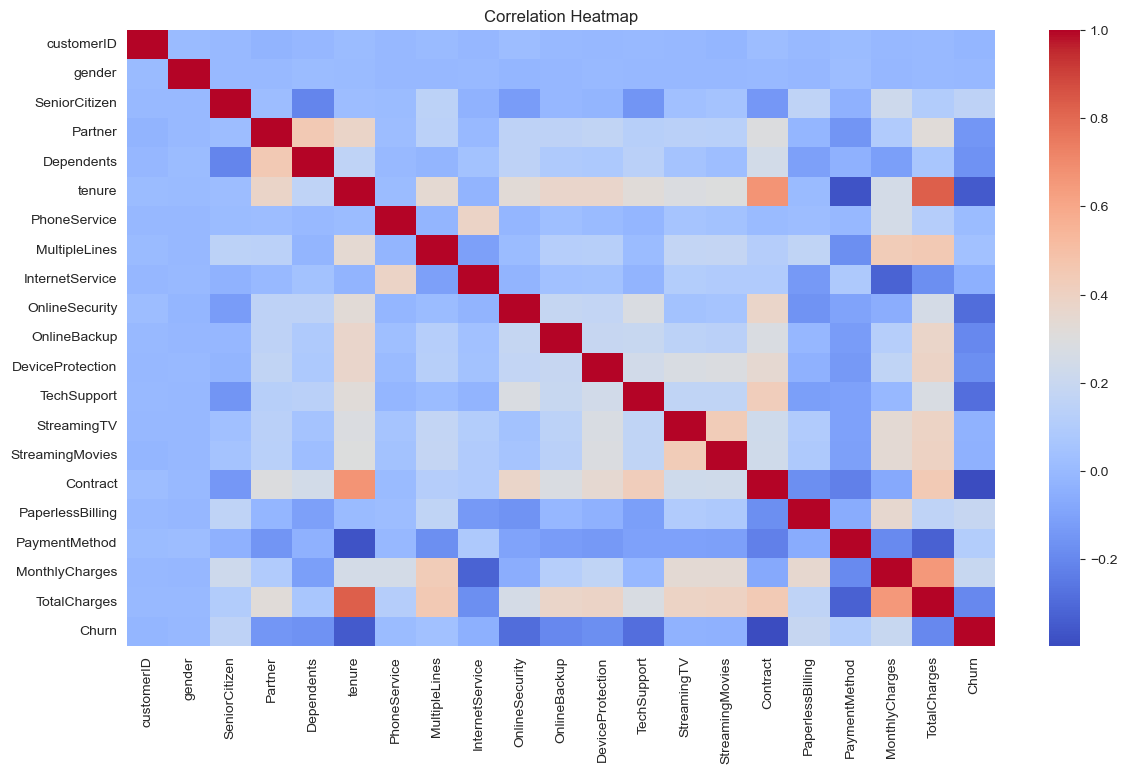

In [77]:
plt.figure(figsize=(14,8))

sns.heatmap(
    temp_df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# Executive Summary

Key Findings:

1. Month-to-month contracts show highest churn.

2. Customers with shorter tenure are at greater risk.

3. Higher monthly charges increase churn probability.

4. Fiber optic customers churn more frequently.

5. Contract type and tenure are likely strong predictors.

### Contract Type vs Churn

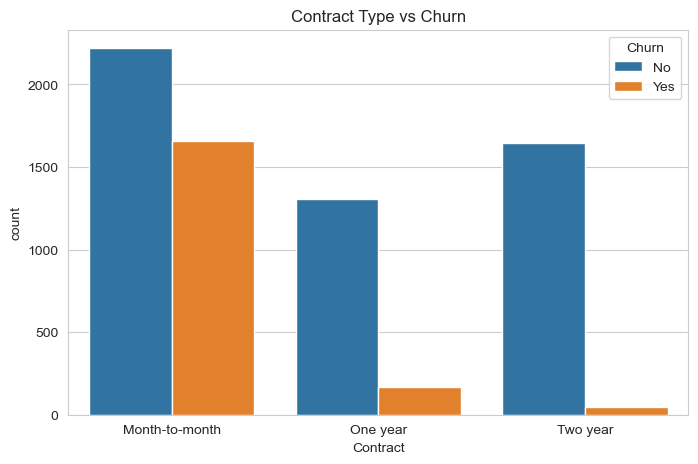

In [78]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Contract Type vs Churn")
plt.show()

Business Insight:

Customers with Month-to-Month contracts show the highest churn rate.

Long-term contracts improve customer retention.

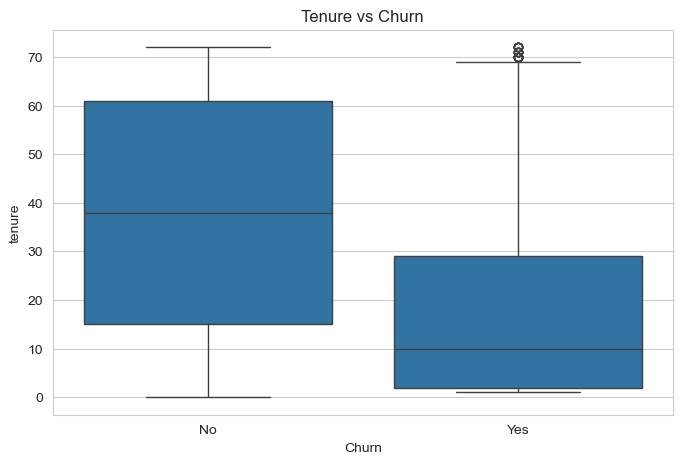

In [79]:
# Tenure vs Churn
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure vs Churn")
plt.show()

Business Insight:

Customers with lower tenure are more likely to churn.

Long-term customers tend to remain loyal.

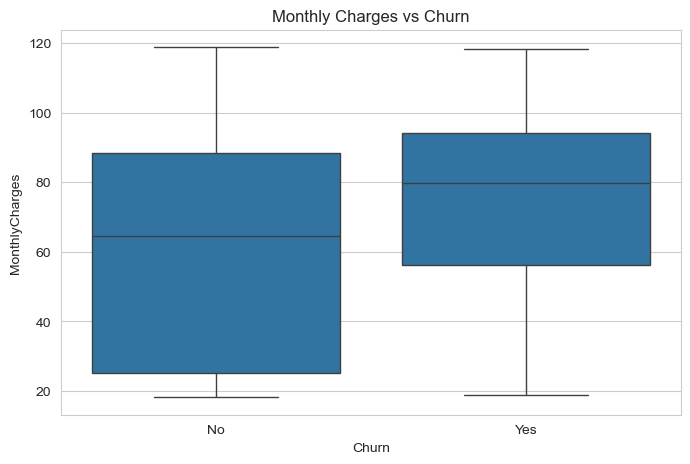

In [80]:
#Monthly Charges vs Churn

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.show()

Business Insight:

Customers paying higher monthly charges show higher churn probability.

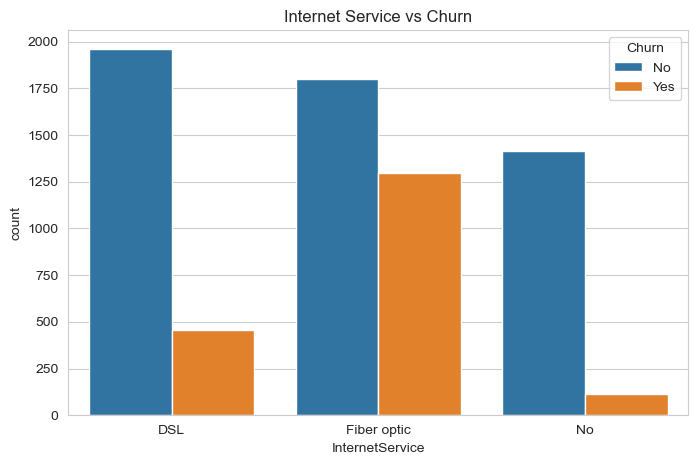

In [81]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Internet Service vs Churn")
plt.show()

Business Insight:

Fiber Optic customers appear to churn more frequently than DSL customers.

##### Payment Method vs Churn


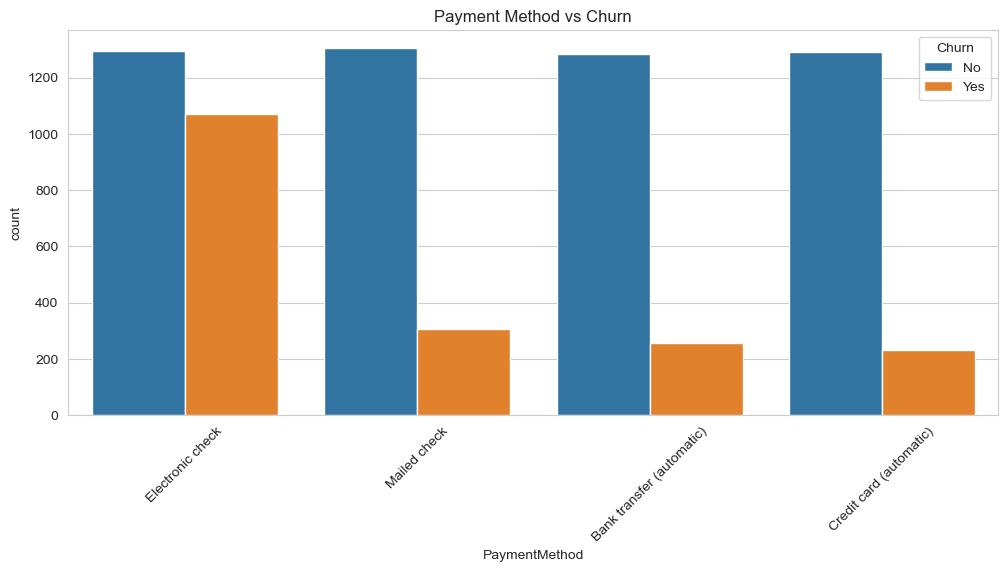

In [82]:
plt.figure(figsize=(12,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

#### Correlation Heatmap

In [83]:
from sklearn.preprocessing import LabelEncoder

temp_df = df.copy()

le = LabelEncoder()

for col in temp_df.columns:
    if temp_df[col].dtype == "object":
        temp_df[col] = le.fit_transform(temp_df[col])

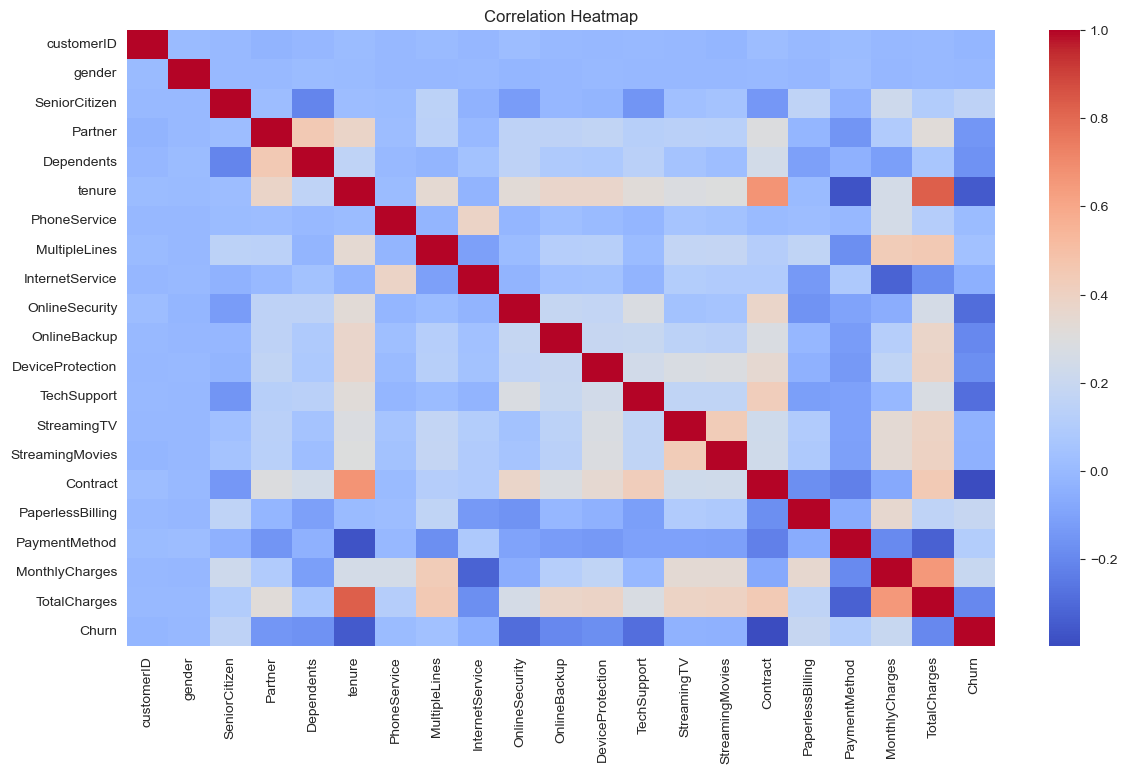

In [84]:
plt.figure(figsize=(14,8))

sns.heatmap(
    temp_df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# Executive Summary

Key Findings:

1. Approximately 26.5% of customers churn.

2. Month-to-Month contracts have the highest churn.

3. Customers with shorter tenure are more likely to leave.

4. Higher monthly charges increase churn risk.

5. Fiber Optic customers show elevated churn rates.

6. Contract type, tenure, and monthly charges are likely strong predictors of churn.